# 2.2 POLLUTION DATA EXPLORATION
Project AirTS-Forecast

Report Section 2 Data Gathering and Exploration
Project WBS 1.2

Author: Tiago TOLOCZKO ROSS

## Description
Welcome to the ultimate report for the pollution data exploration phase

## 2.2.1 Data Source

Website: https://www.geodair.fr/donnees/api

ZAS Code: FR76ZAG01

Start Date: 21/03/2021 00:01

End Date: 21/03/2026 00:01

Data type: a1


In [1]:
%%html
<iframe width="600" height="165" src="https://www.geodair.fr/donnees/api" frameborder='0' allowfullscreen position="relative" left="500"></iframe>

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from pollution_data_exp_core import (
    parse_pollution_metadata,
    pollution_data_resampling,
    visualize_pollution_timeseries,
    fourier_analysis,
    visualize_fourier_spectrum,
    analyze_stationarity_trend,
    visualize_trend_analysis,
    analyze_stl_decomposition,
    visualize_stl_decomposition,
    analyze_memory,
    visualize_correlogram
)
from pollution_data_exp_pollutants_comparison import (
    get_analysis_pollutants,
    visualize_multiple_spectra
)

PROJECT_DIRECTORY = r"C:\Users\Tiago\Documents - PC\UTTOP\Enseignements\M1.2\Projet AirTS - Forecast"
POLLUTION_DATA_DIRECTORY = Path(PROJECT_DIRECTORY+r"\GEODAIR_POLLUTION_DATA")
OUTPUT_PLOT_DIRECTORY = Path(PROJECT_DIRECTORY+r"\POLLUTION PLOTS")

letters = 'abcdefgh'

PERIODICITY = "hourly"

file_encoding_kwargs = {    # File settings
    "sep": ";",
    "encoding": "utf-8",
}

presentation_kwargs = {
    "figsize": (5,2),
    "color": "teal",
    "markerfacecolor": "black",
    "markeredgecolor": "black",
    "marker": "o",
    "xlabel": "Observation Timestamp",
    "ylabel": "Concentration",
    "unit": "µg/m³",
}

In [3]:
data_files = []
pollutants = []

DATA_DICT_2 = get_analysis_pollutants(POLLUTION_DATA_DIRECTORY, periodicity="hourly", apply_cleaning=False, diff_order=2)

for file in POLLUTION_DATA_DIRECTORY.iterdir():
    data_files.append(file)
    meta = parse_pollution_metadata(str(file.name))
    df,data_series=pollution_data_resampling(
        file,
        kwargs=file_encoding_kwargs
    )

    pollutants.append(meta["pollutant"])
    print("#"*80)
    print(f"Target Pollutant:       {meta['pollutant']}")
    print(f"Temporal Bounds:        {meta['start_date'].date()} to {meta['end_date'].date()}")
    print(f"Raw Data Points:        {len(df)}")
    print(f"Cleaned Periods ({PERIODICITY[0].upper()}): {len(data_series)}")
    print(f"Global Arithmetic Mean: {df['valeur'].mean():.4f}\n")


################################################################################
Target Pollutant:       NO2
Temporal Bounds:        2021-03-21 to 2026-03-21
Raw Data Points:        220296
Cleaned Periods (H): 43824
Global Arithmetic Mean: 18.3000

################################################################################
Target Pollutant:       NOx
Temporal Bounds:        2021-03-21 to 2026-03-21
Raw Data Points:        220296
Cleaned Periods (H): 43824
Global Arithmetic Mean: 28.3226

################################################################################
Target Pollutant:       O3
Temporal Bounds:        2021-03-21 to 2026-03-21
Raw Data Points:        132696
Cleaned Periods (H): 43824
Global Arithmetic Mean: 58.6041

################################################################################
Target Pollutant:       PM10
Temporal Bounds:        2021-03-21 to 2026-03-21
Raw Data Points:        350160
Cleaned Periods (H): 43824
Global Arithmetic Mean: 14.2490

####

## 2.2.2 Time Series

### Order 0 plotting

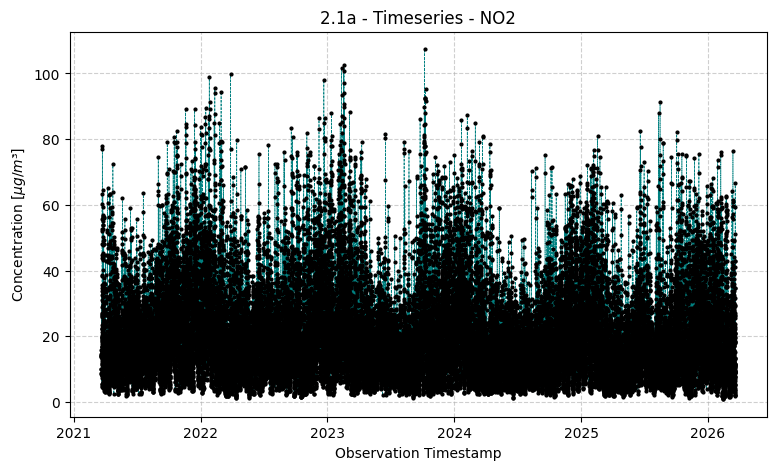

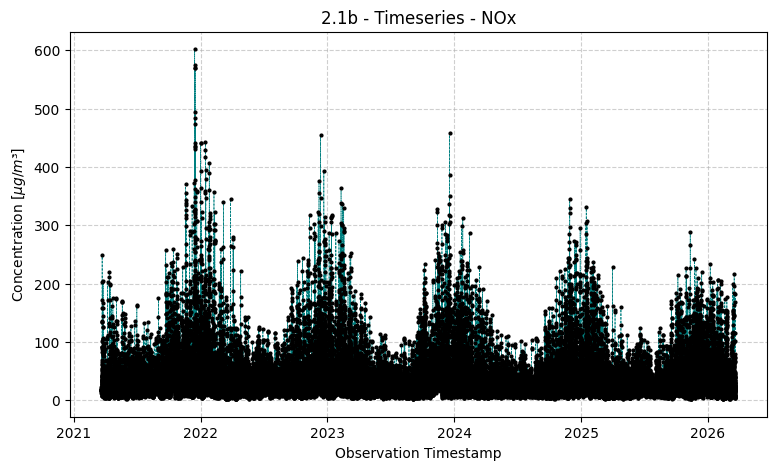

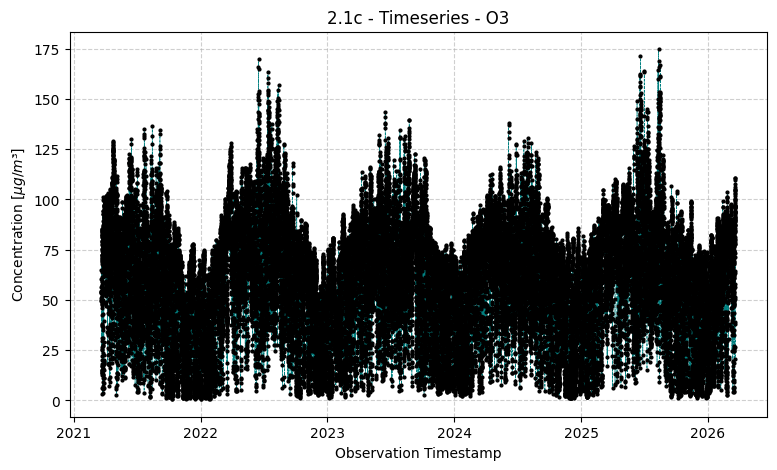

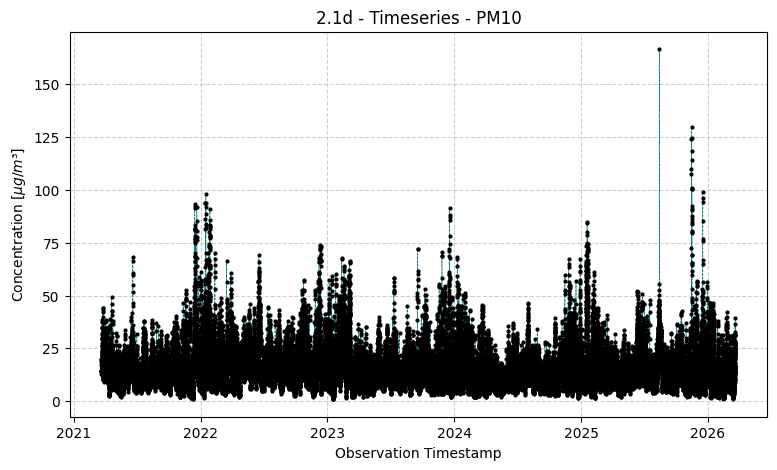

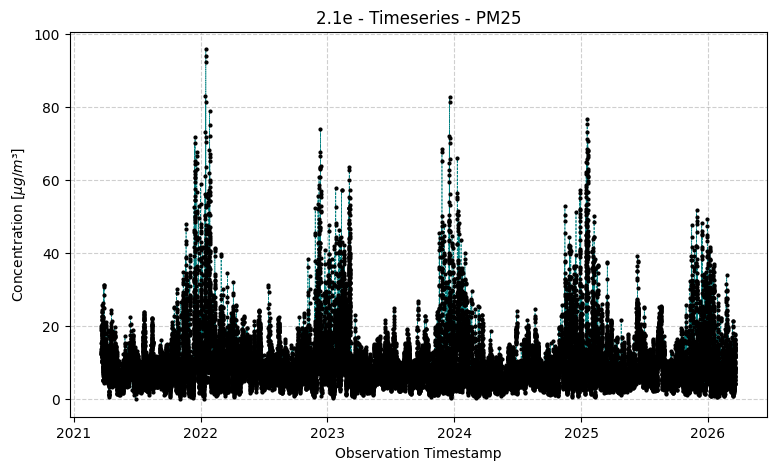

In [4]:
%matplotlib inline
presentation_kwargs["figsize"] = (9,3)

for idx, pollutant in enumerate(DATA_DICT_2.keys()):
    title = f"2.1{letters[idx]} - Timeseries - {pollutant}"
    data_series=DATA_DICT_2[pollutant][1][2]

    time_series = visualize_pollution_timeseries(
        data_series,
        title=title,
        **presentation_kwargs)

    if time_series is not None:
        plt.show()

        time_series.savefig(OUTPUT_PLOT_DIRECTORY/f"{title}.png")


### Higher differentiation order visualization

To ascertain that the series carry no trends to the ARIMA model, it is recommended to apply differentiation. Here is one example of the NO2 time series and its first and second order derivatives. It is possible to infer that the first order should suffice to eliminate trends and

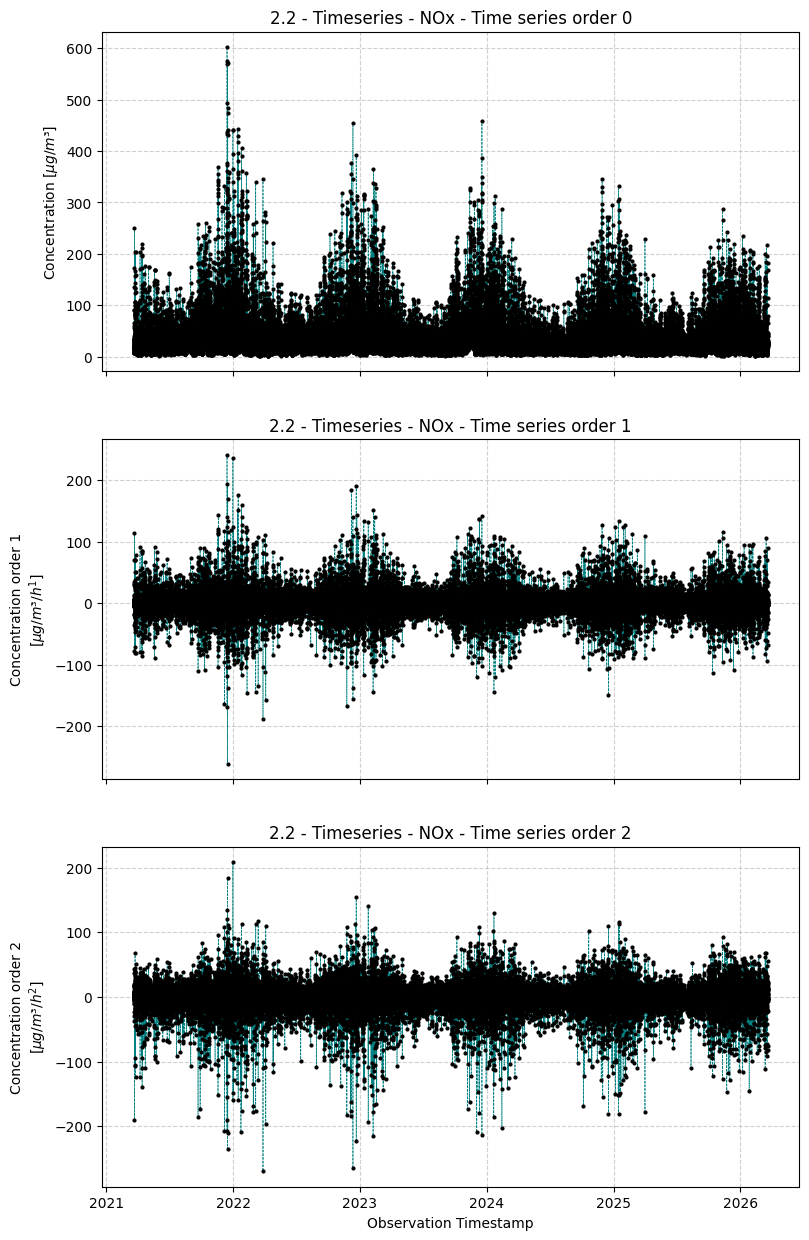

In [5]:
%matplotlib inline

presentation_kwargs["figsize"] = (9,3)
idx=0
# NO2 for example
pollutant = "NOx"

title = f"2.2 - Timeseries - {pollutant}"
data_series=DATA_DICT_2[pollutant][1]

time_series = visualize_pollution_timeseries(
    data_series,
    title=title,
    **presentation_kwargs)

if time_series is not None:
    plt.show()

    time_series.savefig(OUTPUT_PLOT_DIRECTORY/f"{title}.png")

## 2.2.3 Power Spectral Density analysis

In [6]:
presentation_kwargs["figsize"] = (5,2)

for idx, pollutant in enumerate(DATA_DICT_2.keys()):
    data_series=DATA_DICT_2[pollutant][1][2]

    df, series, fft_summary = fourier_analysis(
        data_series,
        periodicity=PERIODICITY,
        top_k=5)

    print(f"\n--- SPECTRAL TREND INDICATORS - {pollutant}---")
    print(f"Primary Target Cycle: {fft_summary['expected_cycle_label']}")
    for rank, (p, a) in enumerate(zip(fft_summary['dominant_periods_raw'], fft_summary['dominant_amplitudes']), 1):
        print(f"Rank {rank} Peak: T={p:<6} | Amp={a}")
    print(f"Variance Captured:    {fft_summary['signal_variance_captured']}%")




--- SPECTRAL TREND INDICATORS - NO2---
Primary Target Cycle: Daily Cycle (Hours)
Rank 1 Peak: T=12.0   | Amp=3.3046
Rank 2 Peak: T=8764.8 | Amp=2.2225
Rank 3 Peak: T=24.0   | Amp=1.4026
Rank 4 Peak: T=167.91 | Amp=0.9967
Rank 5 Peak: T=43824.0 | Amp=0.9576
Variance Captured:    23.03%

--- SPECTRAL TREND INDICATORS - NOx---
Primary Target Cycle: Daily Cycle (Hours)
Rank 1 Peak: T=8764.8 | Amp=9.4586
Rank 2 Peak: T=12.0   | Amp=9.1513
Rank 3 Peak: T=12.02  | Amp=3.4641
Rank 4 Peak: T=4382.4 | Amp=3.4262
Rank 5 Peak: T=11.98  | Amp=3.0066
Variance Captured:    24.73%

--- SPECTRAL TREND INDICATORS - O3---
Primary Target Cycle: Daily Cycle (Hours)
Rank 1 Peak: T=8764.8 | Amp=8.7147
Rank 2 Peak: T=24.0   | Amp=8.0086
Rank 3 Peak: T=4382.4 | Amp=3.2734
Rank 4 Peak: T=12.0   | Amp=2.8611
Rank 5 Peak: T=23.93  | Amp=2.6314
Variance Captured:    42.64%

--- SPECTRAL TREND INDICATORS - PM10---
Primary Target Cycle: Daily Cycle (Hours)
Rank 1 Peak: T=12.0   | Amp=1.0306
Rank 2 Peak: T=4382.4 | 

### Graphical representation of different pollutants

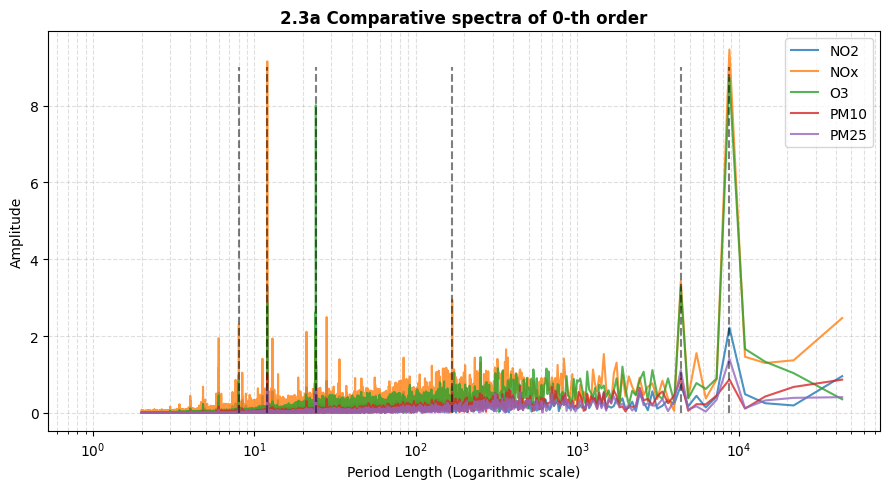

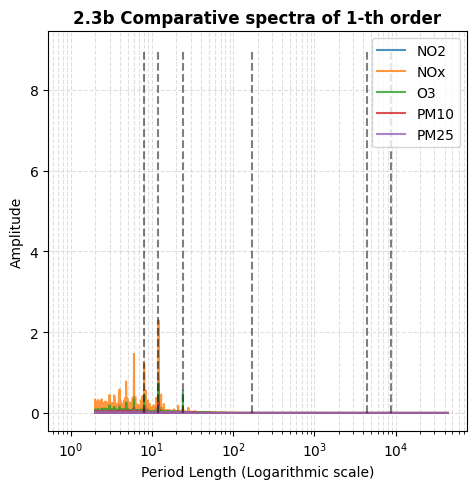

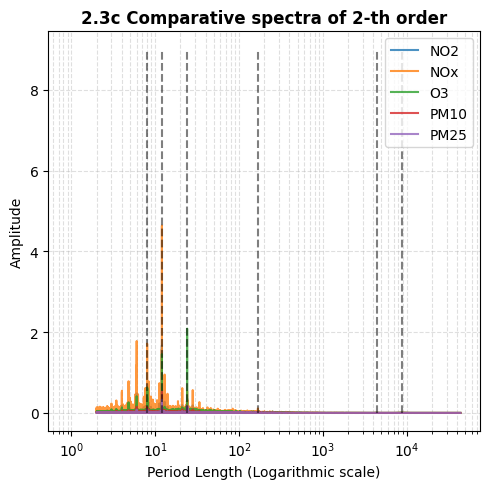

In [7]:
presentation_kwargs["figsize"] = (5,5)

for i in range(3):
    if i == 0:
        presentation_kwargs["figsize"] = (9,5)
    else:
        presentation_kwargs["figsize"] = (5,5)
    ith_data_dict = {}
    for pollutant in DATA_DICT_2.keys():
        ith_data_dict[pollutant] = DATA_DICT_2[pollutant][1][i-1]
    title=f"2.3{letters[i]} Comparative spectra of {i}-th order"
    fig = visualize_multiple_spectra(
        data_dict=ith_data_dict,
        top_k=0,
        save_file=True,
        title=title,
        save_folder=OUTPUT_PLOT_DIRECTORY,
        **presentation_kwargs
    )

    plt.vlines([8,12,24,168,24*365/2,24*365],0,9 ,linestyle="--", color="black",alpha=0.5)
    plt.savefig(OUTPUT_PLOT_DIRECTORY/Path(title+".png"))
    plt.show(fig)




### Trend Analysis

### NO2 exploration

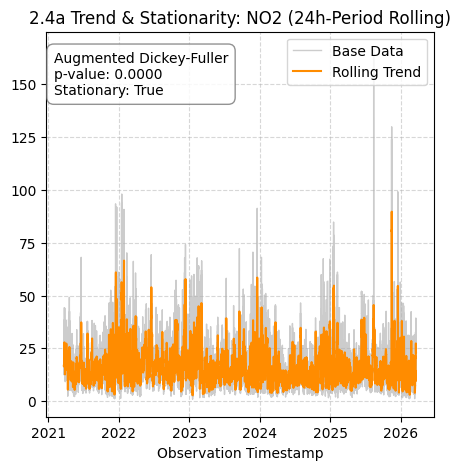

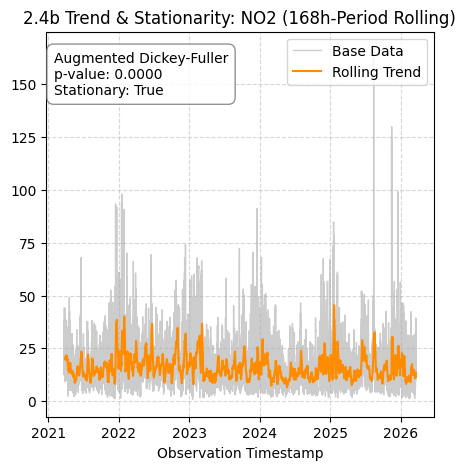

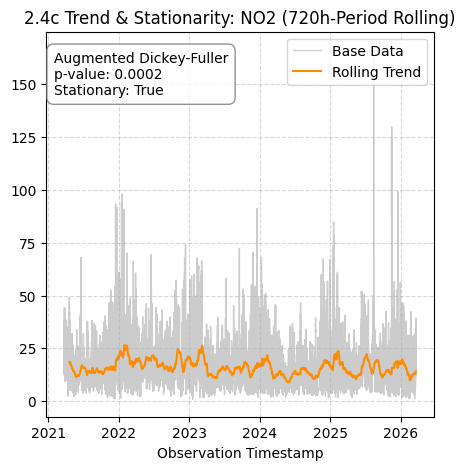

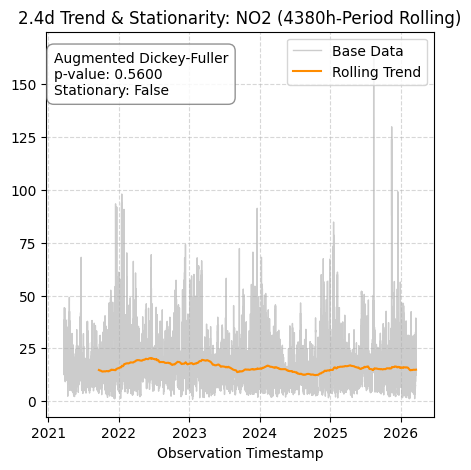

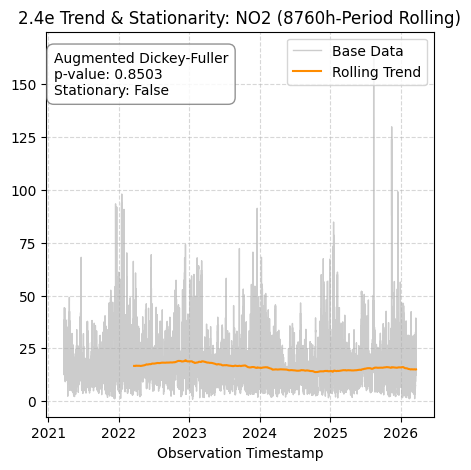

In [8]:
explorated_windows = [24,168,24*30,24*365//2,24*365]
presentation_kwargs["figsize"] = (5,5)

for idx, window_size in enumerate(explorated_windows):
    target_data = DATA_DICT_2["PM10"][1][2]
    trend_data, adf_summary = analyze_stationarity_trend(
        target_data, window_size=window_size, **presentation_kwargs
    )
    title = f"2.4{letters[idx]} Trend & Stationarity: PM10 ({window_size}h-Period Rolling)"
    trend_fig = visualize_trend_analysis(
        raw_input=target_data,
        trend_input=trend_data,
        adf_summary=adf_summary,
        title=title,
        **presentation_kwargs
        )

    plt.savefig(OUTPUT_PLOT_DIRECTORY/Path(title+".png"))

    if trend_fig:
        plt.show()


### All pollutants


--- STATIONARITY REPORT ---
NO2 at 24h: p-value = 0.0000 | Stationary = True


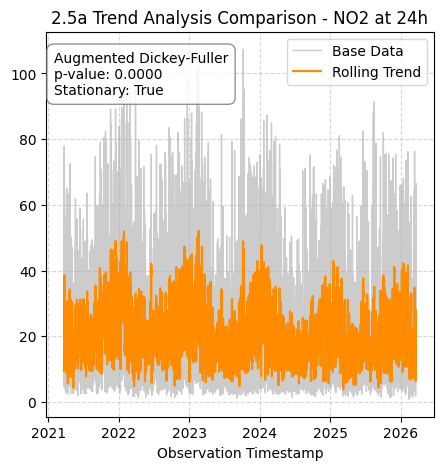

NO2 at 4380h: p-value = 0.7011 | Stationary = False


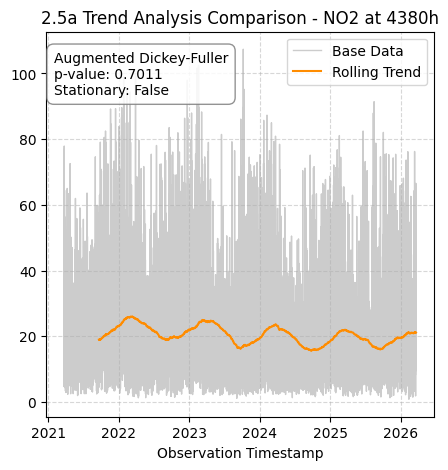


--- STATIONARITY REPORT ---
NOx at 24h: p-value = 0.0000 | Stationary = True


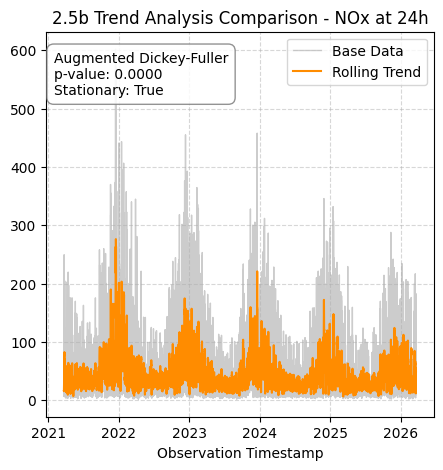

NOx at 4380h: p-value = 0.5957 | Stationary = False


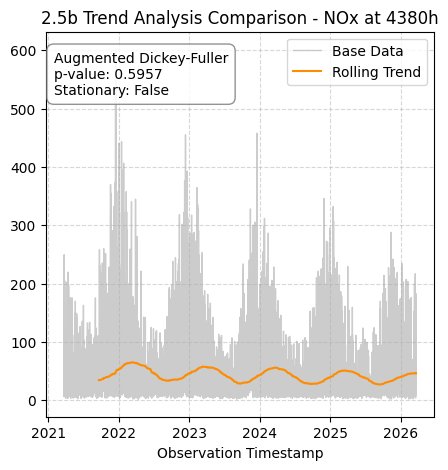


--- STATIONARITY REPORT ---
O3 at 24h: p-value = 0.0000 | Stationary = True


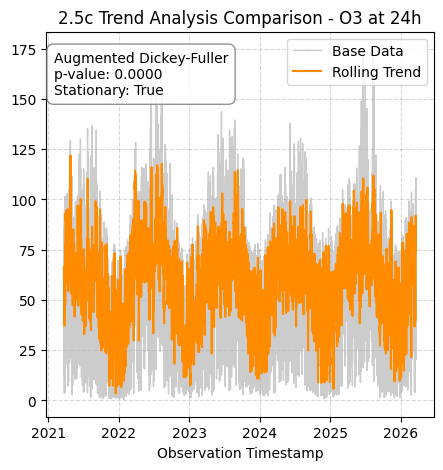

O3 at 4380h: p-value = 0.5588 | Stationary = False


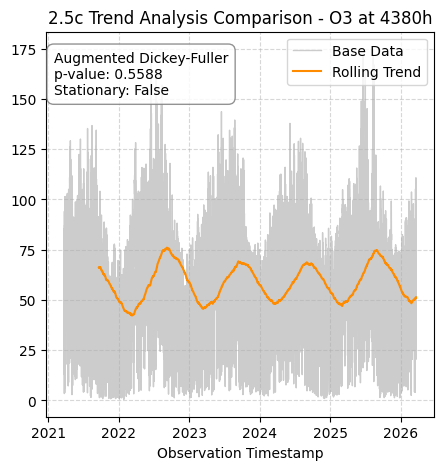


--- STATIONARITY REPORT ---
PM10 at 24h: p-value = 0.0000 | Stationary = True


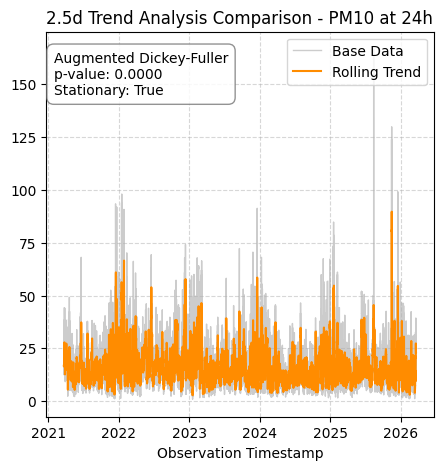

PM10 at 4380h: p-value = 0.5600 | Stationary = False


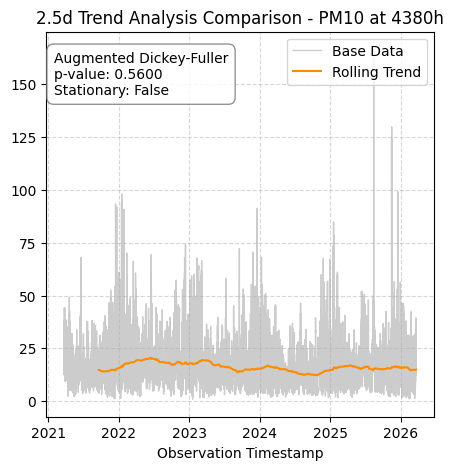


--- STATIONARITY REPORT ---
PM25 at 24h: p-value = 0.0000 | Stationary = True


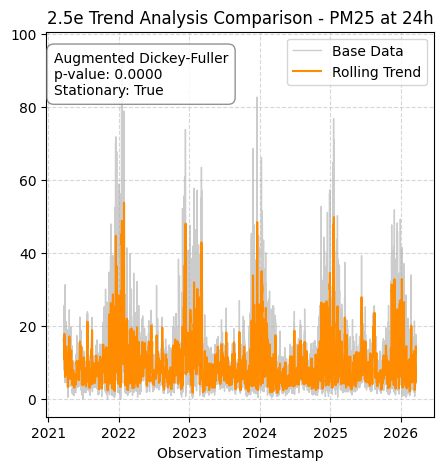

PM25 at 4380h: p-value = 0.4578 | Stationary = False


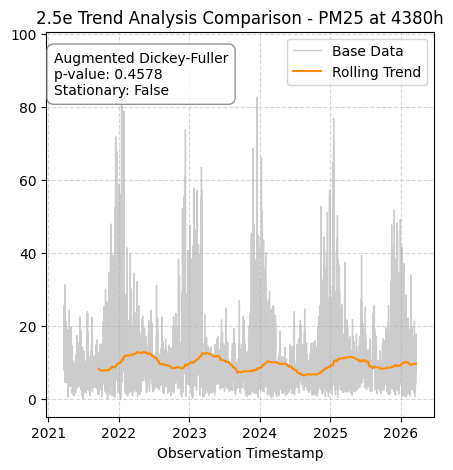

In [9]:
explorated_windows = [24,24*365//2]

for idx, pollutant in enumerate(DATA_DICT_2.keys()):
    target_data = DATA_DICT_2[pollutant][1][2]

    print("\n--- STATIONARITY REPORT ---")


    for jdx, window_size in enumerate(explorated_windows):
        title = f"2.5{letters[idx]} Trend Analysis Comparison - {pollutant} at {window_size}h"

        trend_data, adf_summary = analyze_stationarity_trend(
            target_data, window_size=window_size, **presentation_kwargs
        )

        trend_fig = visualize_trend_analysis(
            raw_input=target_data,
            trend_input=trend_data,
            adf_summary=adf_summary,
            title=title,
            **presentation_kwargs
        )
        plt.savefig(OUTPUT_PLOT_DIRECTORY/Path(title+".png"))

        series_key = f"{pollutant} at {window_size}h"
        p_val = adf_summary.get('p_value')
        is_stat = adf_summary.get('is_stationary', 'Unknown')
        if p_val is not None:
            print(f"{series_key}: p-value = {p_val:.4f} | Stationary = {is_stat}")
        else:
            print(f"{series_key}: Failed -> Missing p-value in statistics.")

        plt.show()


## 2.2.4 STL Decomposition

### All pollutants


In [ ]:
presentation_kwargs["figsize"] = (5,5)
period_window = 24*365//2
seasonal_window = 24*365//2
print("\n--- STL DECOMPOSITION INDICATORS ---")

for idx, pollutant in enumerate(DATA_DICT_2.keys()):
    title = f"2.6{letters[idx]} STL decompostion - {pollutant}"
    target_series = DATA_DICT_2[pollutant][1][2]

    primary_df, primary_summary = analyze_stl_decomposition(
        target_series, period=period_window, seasonal=seasonal_window, robust=False, **presentation_kwargs
    )
    robust_df, robust_summary = analyze_stl_decomposition(
        target_series, seasonal=seasonal_window, robust=True, **presentation_kwargs
    )

    if not primary_df.empty:
        valid_secondary = robust_df if not robust_df.empty else None
        secondary_lbl = "Robust Fit" if valid_secondary is not None else None

        stl_fig = visualize_stl_decomposition(
            primary_decomp=primary_df,
            primary_summary=primary_summary,
            title=f"2.7{letters[idx]} STL Comparison: Standard vs Robust {pollutant}",
            secondary_decomp=valid_secondary,
            secondary_label=secondary_lbl,
            **presentation_kwargs
        )
        plt.savefig(OUTPUT_PLOT_DIRECTORY/Path(title+".png"))

    print(f"\n--- {pollutant} ---")
    print(f"Seasonal Window:        {primary_summary.get('seasonal_window')}")
    print(f"Standard Trend Str:     {primary_summary.get('trend_strength', 0):.4f}")
    print(f"Standard Seasonal Str:  {primary_summary.get('seasonal_strength', 0):.4f}")

    if robust_summary and not robust_df.empty:
        print(f"Robust Trend Str:       {robust_summary.get('trend_strength', 0):.4f}")
        print(f"Robust Seasonal Str:    {robust_summary.get('seasonal_strength', 0):.4f}")

    plt.show()


### Order 1 comparison

In [ ]:
target_series = DATA_DICT_2["NO2"][1][1]
period_window = 24*365//2
seasonal_window = 24*365//2

primary_df, primary_summary = analyze_stl_decomposition(
    target_series, period=period_window, seasonal=seasonal_window, robust=False, **presentation_kwargs
)
robust_df, robust_summary = analyze_stl_decomposition(
    target_series, seasonal=seasonal_window, robust=True, **presentation_kwargs
)

if not primary_df.empty:
    valid_secondary = robust_df if not robust_df.empty else None
    secondary_lbl = "Robust Fit" if valid_secondary is not None else None

    stl_fig = visualize_stl_decomposition(
        primary_decomp=primary_df,
        primary_summary=primary_summary,
        title=f"2.8 STL Comparison: Standard vs Robust NO2 at Order 2",
        secondary_decomp=valid_secondary,
        secondary_label=secondary_lbl,
        **presentation_kwargs
    )
    plt.savefig(OUTPUT_PLOT_DIRECTORY/Path(title+".png"))

print(f"\n--- NO2 Order 1 ---")
print(f"Seasonal Window:        {primary_summary.get('seasonal_window')}")
print(f"Standard Trend Str:     {primary_summary.get('trend_strength', 0):.4f}")
print(f"Standard Seasonal Str:  {primary_summary.get('seasonal_strength', 0):.4f}")

if robust_summary and not robust_df.empty:
    print(f"Robust Trend Str:       {robust_summary.get('trend_strength', 0):.4f}")
    print(f"Robust Seasonal Str:    {robust_summary.get('seasonal_strength', 0):.4f}")

plt.show()

## Memory Analysis


### All pollutants, ACF and PACF order 0

In [ ]:
presentation_kwargs["figsize"] = (9,4)
memory_kwargs = presentation_kwargs.copy()

for idx, pollutant in enumerate(DATA_DICT_2.keys()):
    title = f"2.6{letters[idx]} STL decompostion - {pollutant}"
    target_series = DATA_DICT_2[pollutant][1][2]

    acf_vals, pacf_vals, memory_summary = analyze_memory(target_series, alpha=0.05, nlags=48)


    if acf_vals.size > 0:
        plot_stats = {
            "extended_results": memory_summary.get("acf_extended_results"),
            "pacf_extended_results": memory_summary.get("pacf_extended_results")
        }
        acf_fig = visualize_correlogram(
            acf_values=acf_vals,
            pacf_values=pacf_vals,
            additional_stats=plot_stats,
            title=f"2.9{letters[idx]} Autocorrelation (ACF and PACF): {pollutant} Memory Profile",
            **memory_kwargs
        )

        plt.savefig(OUTPUT_PLOT_DIRECTORY/Path(title+".png"))
        if acf_fig:
            plt.show()
            plt.close(acf_fig)

    if memory_summary:
        print("\n--- MEMORY & AUTOCORRELATION INDICATORS ---")
        print(f"Max Lag Evaluated:      {memory_summary.get('max_lag_evaluated')}")
        print(f"Significance Threshold: alpha = {memory_summary.get('alpha_threshold')}")

        acf_sig = memory_summary.get('significant_acf_lags', [])
        pacf_sig = memory_summary.get('significant_pacf_lags', [])

        print(f"Significant ACF Lags:   {acf_sig[:15]}{'...' if len(acf_sig) > 15 else ''}")
        print(f"Significant PACF Lags:  {pacf_sig[:15]}{'...' if len(pacf_sig) > 15 else ''}")

### All pollutants, ACF and PACF order 1
Since it is important for ARIMA and SARIMA models to have the ACF data from the first order differentiation model, we'll plot these for all pollutants

In [ ]:
presentation_kwargs["figsize"] = (9,4)
memory_kwargs = presentation_kwargs.copy()

for idx, pollutant in enumerate(DATA_DICT_2.keys()):
    title = f"2.6{letters[idx]} STL decompostion - {pollutant}"
    target_series = DATA_DICT_2[pollutant][1][1]

    acf_vals, pacf_vals, memory_summary = analyze_memory(target_series, alpha=0.05, nlags=48)


    if acf_vals.size > 0:
        plot_stats = {
            "extended_results": memory_summary.get("acf_extended_results"),
            "pacf_extended_results": memory_summary.get("pacf_extended_results")
        }
        acf_fig = visualize_correlogram(
            acf_values=acf_vals,
            pacf_values=pacf_vals,
            additional_stats=plot_stats,
            title=f"2.10{letters[idx]} Autocorrelation (ACF and PACF) order 1: {pollutant} Memory Profile",
            **memory_kwargs
        )

        plt.savefig(OUTPUT_PLOT_DIRECTORY/Path(title+".png"))
        if acf_fig:
            plt.show()
            plt.close(acf_fig)

    if memory_summary:
        print(f"\n--- MEMORY & AUTOCORRELATION INDICATORS Order 1 {pollutant} MEMORY PROFILE ---")
        print(f"Max Lag Evaluated:      {memory_summary.get('max_lag_evaluated')}")
        print(f"Significance Threshold: alpha = {memory_summary.get('alpha_threshold')}")

        acf_sig = memory_summary.get('significant_acf_lags', [])
        pacf_sig = memory_summary.get('significant_pacf_lags', [])

        print(f"Significant ACF Lags:   {acf_sig[:15]}{'...' if len(acf_sig) > 15 else ''}")
        print(f"Significant PACF Lags:  {pacf_sig[:15]}{'...' if len(pacf_sig) > 15 else ''}")

### All pollutants, ACF and PACF order 1

In [ ]:
presentation_kwargs["figsize"] = (9,4)
memory_kwargs = presentation_kwargs.copy()

for idx, pollutant in enumerate(DATA_DICT_2.keys()):
    title = f"2.6{letters[idx]} STL decompostion - {pollutant}"
    target_series = DATA_DICT_2[pollutant][1][0]

    acf_vals, pacf_vals, memory_summary = analyze_memory(target_series, alpha=0.05, nlags=48)


    if acf_vals.size > 0:
        plot_stats = {
            "extended_results": memory_summary.get("acf_extended_results"),
            "pacf_extended_results": memory_summary.get("pacf_extended_results")
        }
        acf_fig = visualize_correlogram(
            acf_values=acf_vals,
            pacf_values=pacf_vals,
            additional_stats=plot_stats,
            title=f"2.11{letters[idx]} Autocorrelation (ACF and PACF) order 2: {pollutant} Memory Profile",
            **memory_kwargs
        )

        plt.savefig(OUTPUT_PLOT_DIRECTORY/Path(title+".png"))
        if acf_fig:
            plt.show()
            plt.close(acf_fig)

    if memory_summary:
        print(f"\n--- MEMORY & AUTOCORRELATION INDICATORS Order 2 {pollutant} MEMORY PROFILE ---")
        print(f"Max Lag Evaluated:      {memory_summary.get('max_lag_evaluated')}")
        print(f"Significance Threshold: alpha = {memory_summary.get('alpha_threshold')}")

        acf_sig = memory_summary.get('significant_acf_lags', [])
        pacf_sig = memory_summary.get('significant_pacf_lags', [])

        print(f"Significant ACF Lags:   {acf_sig[:15]}{'...' if len(acf_sig) > 15 else ''}")
        print(f"Significant PACF Lags:  {pacf_sig[:15]}{'...' if len(pacf_sig) > 15 else ''}")